In [3]:
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt

In [15]:
preds_csv_dir = r"\\zkh\appdata\RTDicom\Projectline_HNC_modelling\Users\Daniel MacRae\1. MultiTox_HNC\Feb_2025_results\Trial_32\ensemble_predictions.csv"

preds_csv_dir = r"\\zkh\appdata\RTDicom\Projectline_HNC_modelling\Users\Daniel MacRae\1. MultiTox_HNC\Feb_2025_results\Trial32_singletox_models\all_ST_models_ens_predictions.csv"

#preds_csv_dir = r"\\zkh\appdata\RTDicom\Projectline_HNC_modelling\Users\Daniel MacRae\1. MultiTox_HNC\VM\TRP_only_photons\ensemble_predictions.csv"
#preds_csv_dir = r"\\zkh\appdata\RTDicom\Projectline_HNC_modelling\Users\Daniel MacRae\1. MultiTox_HNC\Feb_2025_new_patients\ensemble_predictions_PRIMA.csv"
#

# preds_csv_dir = r"\\zkh\appdata\RTDicom\Projectline_HNC_modelling\Users\Daniel MacRae\1. MultiTox_HNC\Feb_2025_results\Trial32_endpoint_combinations\salivary_domain\ensemble_predictions.csv"  # SALIVARY ONLY

#preds_csv_dir = r"\\zkh\appdata\RTDicom\Projectline_HNC_modelling\Users\Daniel MacRae\1. MultiTox_HNC\Feb_2025_results\Trial_32\LR_ensemble_preds.csv"


df_preds = pd.read_csv(preds_csv_dir, sep=';')
df_preds['PatientID'] = df_preds['PatientID'].astype(str).str.zfill(7)



df_preds


,PatientID,Mode,Aspiration_M06_pred,Aspiration_M06_true,Dysphagia_M06_pred,Dysphagia_M06_true,Sticky_M06_pred,Sticky_M06_true,Taste_M06_pred,Taste_M06_true,Xerostomia_M06_pred,Xerostomia_M06_true
0,0052277,test,0.045099,0.0,0.546940,-1.0,0.314537,0.0,0.349050,1.0,0.477745,0.0
1,0066593,test,0.163455,0.0,0.351666,0.0,0.376605,0.0,0.275210,0.0,0.446016,0.0
2,0092560,test,0.040938,0.0,0.259018,0.0,0.336065,0.0,0.357305,0.0,0.478015,0.0
3,0163517,test,0.055559,0.0,0.048854,0.0,0.160795,0.0,0.081966,0.0,0.107219,0.0
4,0213240,test,0.048561,0.0,0.439201,0.0,0.363727,1.0,0.364746,0.0,0.566932,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...
211,9586209,test,0.056359,0.0,0.601831,1.0,0.394297,0.0,0.432805,0.0,0.481655,1.0
212,9597467,test,0.043152,0.0,0.277357,1.0,0.322244,0.0,0.329413,1.0,0.521429,1.0
213,9653665,test,0.077076,0.0,0.197444,0.0,0.337162,1.0,0.500556,1.0,0.517134,1.0
214,9715913,test,0.045609,1.0,0.410751,1.0,0.431505,1.0,0.332410,1.0,0.570101,1.0


In [16]:
all_features_dir = r"\\zkh\appdata\RTDicom\Projectline_HNC_modelling\Users\Daniel MacRae\CITOR_REDCAP_clinical_data_important_variables_combined.xlsx"

df_all_features = pd.read_excel(all_features_dir)

df_all_features['PatientID'] = df_all_features['UMCG'].astype(str).str.zfill(7)

# missing values
df_all_features['Technique'] = df_all_features.apply(
    lambda row: row['Check2'] if row['Technique'] == 0 else row['Technique'], axis=1
)
df_all_features["Chemo"] = df_all_features["Modality"].apply(
    lambda x: 1 if isinstance(x, str) and ("Chemo" in x or "Bioradiation" in x) else 0
)
df_all_features["Loctum2"].value_counts(dropna=False)


replace_dict = {'Larynx': 'Larynx', 
            'Oropharynx' : 'Pharynx', 
            'Hypofarynx' : 'Pharynx',
            'Nasopharynx' : 'Pharynx',
            'Neus(bij)holte' : 'Overig',
            'Categorie: overig' : 'Overig',
            }
df_all_features['Loctum3'] = df_all_features['Loctum2'].replace(replace_dict)
#df_all_features['Technique'] = df_all_features.apply(df_all_features['Technique'])

df_merged = pd.merge(df_preds, df_all_features[['PatientID', "RTSTART", "Technique", "Chemo", "Loctum3"]], on='PatientID', how='left')

df_merged['RTSTART_year'] = pd.to_datetime(df_merged['RTSTART']).dt.year

df_preds = df_merged

In [17]:
df_predictions_only = df_preds[['Aspiration_M06_pred', 'Dysphagia_M06_pred', 'Sticky_M06_pred', 'Taste_M06_pred', 'Xerostomia_M06_pred']].copy()
df_predictions_only.columns = df_predictions_only.columns.str.replace('_pred', '', regex=False)
df_predictions_only

df_labels_only = df_preds[['Aspiration_M06_true', 'Dysphagia_M06_true', 'Sticky_M06_true', 'Taste_M06_true', 'Xerostomia_M06_true']].copy()
df_labels_only.columns = df_labels_only.columns.str.replace('_true', '', regex=False)
df_labels_only

,Aspiration_M06,Dysphagia_M06,Sticky_M06,Taste_M06,Xerostomia_M06
0,0.0,-1.0,0.0,1.0,0.0
1,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,1.0,0.0,1.0
...,...,...,...,...,...
211,0.0,1.0,0.0,0.0,1.0
212,0.0,1.0,0.0,1.0,1.0
213,0.0,0.0,1.0,1.0,1.0
214,1.0,1.0,1.0,1.0,1.0


# ANALYSIS

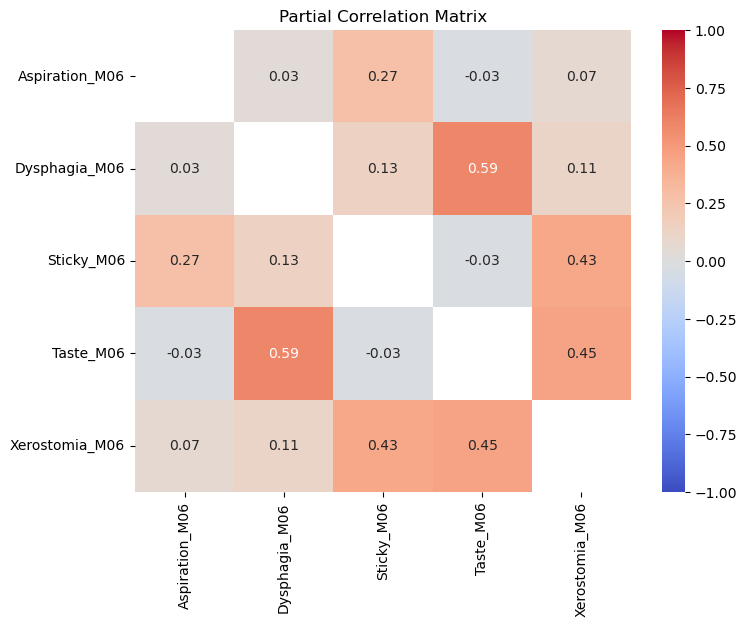

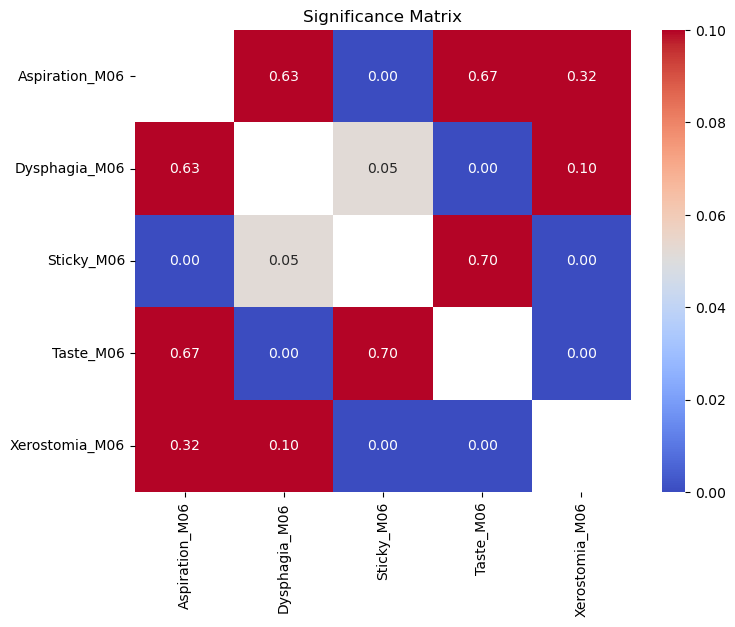

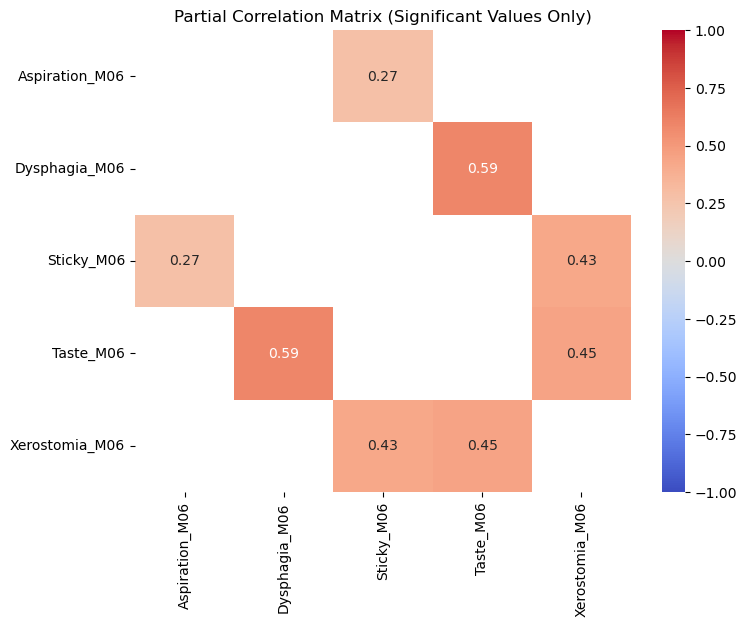

In [18]:
# Inter-Toxicity Correlation Analysis
import pandas as pd
import numpy as np
import seaborn as sns
from pingouin import partial_corr
import matplotlib.pyplot as plt

labels = df_labels_only.copy()
labels.replace(-1, np.nan, inplace=True)
labels.dropna(inplace=True)
predictions = df_predictions_only.copy()
toxicity_columns = predictions.columns.tolist()


# Calculate the partial correlations between toxicity predictions
partial_correlation_matrix = pd.DataFrame(index=toxicity_columns, columns=toxicity_columns)
significance_matrix = pd.DataFrame(index=toxicity_columns, columns=toxicity_columns)

for col1 in toxicity_columns:
    for col2 in toxicity_columns:
        if col1 == col2:
            partial_correlation_matrix.loc[col1, col2] = np.nan  # Self-correlation is 1
            significance_matrix.loc[col1, col2] = np.nan  # No significance for self-correlation
        else:
            # Calculate partial correlation controlling for all other variables
            control_vars = [col for col in toxicity_columns if col not in [col1, col2]]
            result = partial_corr(data=predictions, x=col1, y=col2, covar=control_vars, method='spearman') # , alternative='greater')
            partial_correlation_matrix.loc[col1, col2] = result['r'].values[0]
            significance_matrix.loc[col1, col2] = result['p-val'].values[0]

# Convert to numeric for better readability
partial_correlation_matrix = partial_correlation_matrix.astype(float)
significance_matrix = significance_matrix.astype(float)

# Plot the partial correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(partial_correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.title('Partial Correlation Matrix')
plt.show()

# plot the significance matrix
plt.figure(figsize=(8, 6))
sns.heatmap(significance_matrix, annot=True, cmap='coolwarm', fmt='.2f', vmax=0.1)
plt.title('Significance Matrix')
plt.show()

# Mask non-significant values
mask = significance_matrix > 0.05  # Mask values with p-value > 0.05

# Apply the mask to the partial correlation matrix
masked_partial_corr = partial_correlation_matrix.copy()
masked_partial_corr[mask] = np.nan

# Mask out the top triangle of the heatmap
# for i in range(len(masked_partial_corr)):
#     for j in range(i + 1, len(masked_partial_corr)):
#         masked_partial_corr.iloc[i, j] = np.nan

# Plot the masked partial correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(masked_partial_corr, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1, mask=mask)
plt.title('Partial Correlation Matrix (Significant Values Only)')
plt.show()



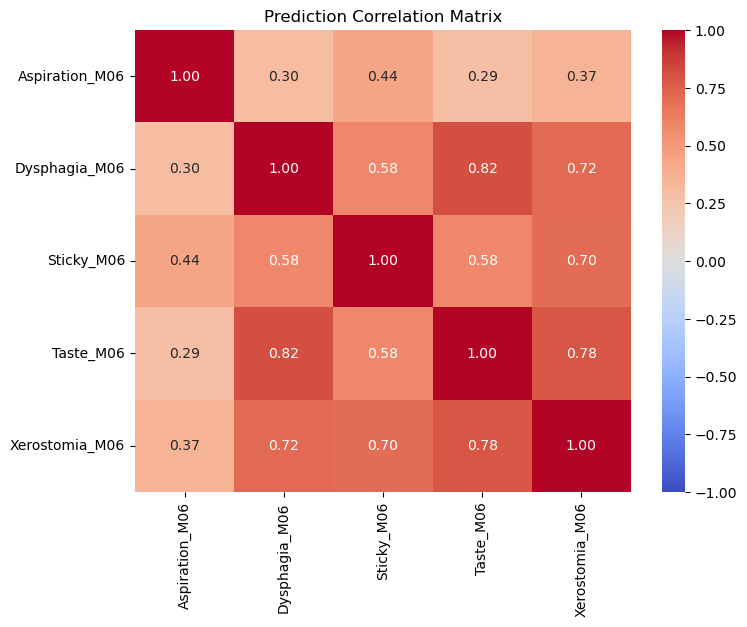

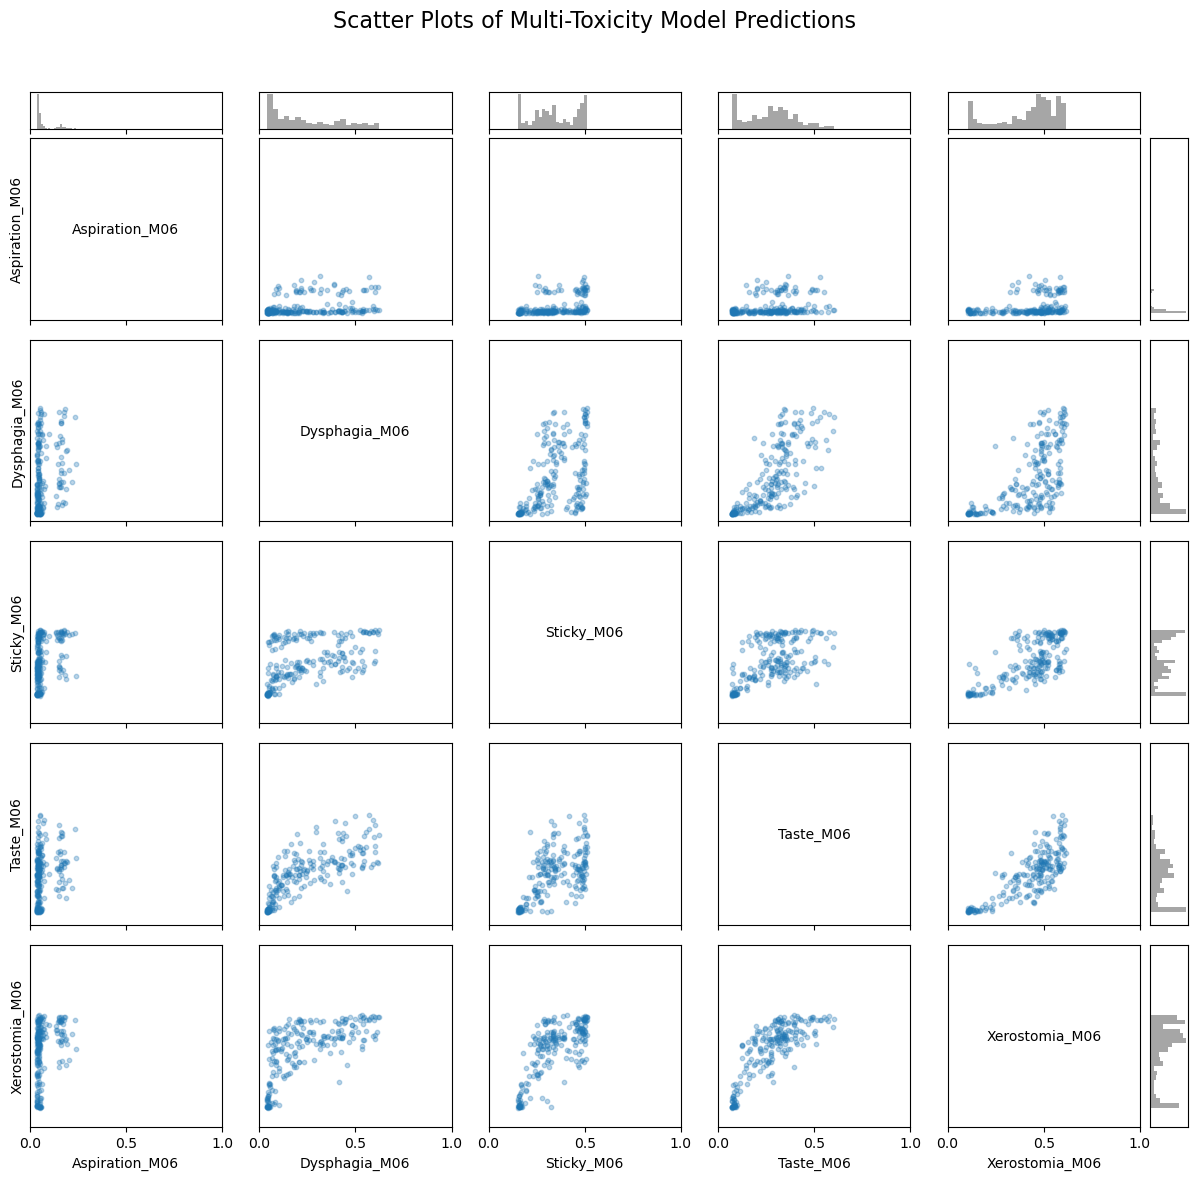

In [19]:
# Inter-Toxicity Correlation Analysis
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Load your predictions DataFrame (replace with actual file path or DataFrame)
predictions = df_predictions_only.copy()  # Replace with your DataFrame loading code

### 1. Prediction Correlation Analysis ###
# Calculate the pairwise correlation between toxicity predictions
correlation_matrix = predictions.corr(method='spearman')

# Plot the correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.title('Prediction Correlation Matrix')
plt.show()

# Create scatter plots for each pair of toxicity predictions
toxicity_columns = predictions.columns
num_toxicities = len(toxicity_columns)

fig, axes = plt.subplots(num_toxicities, num_toxicities, figsize=(12, 12), sharex=True, sharey=True)
fig.suptitle('Scatter Plots of Multi-Toxicity Model Predictions', fontsize=16)

#colour_column = df_preds['Loctum3'].map({'Pharynx': 'b', 'Larynx': 'g', 'Overig': 'r'})

catcol = 'Loctum3'
categories = df_preds[catcol].value_counts().index.tolist()
colors = np.linspace(0, 1, len(categories)) / 2
colordict = dict(zip(categories, colors)) 
df_preds["Color"] = df_preds[catcol].apply(lambda x: colordict[x])

for i, col1 in enumerate(toxicity_columns):
    for j, col2 in enumerate(toxicity_columns):
        ax = axes[i, j]
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        if i == j:
            ax.text(0.5, 0.5, col1, fontsize=10, ha='center', va='center')
            ax.set_xticks([])
            ax.set_yticks([])
        else:
            scatter = ax.scatter(predictions[col2], predictions[col1], s=10, alpha=0.3) # , c=df_preds.Color)#  , cmap='Dark2')
            # if i == 0 and j == 1:  # Add legend only once
            #     handles, labels = scatter.legend_elements(prop="colors", alpha=0.6)
            #     legend_labels = [f"{cat}" for cat in categories]
            #     ax.legend(handles, legend_labels, title=catcol)

        if j == 0:
            ax.set_ylabel(col1)
            ax.set_yticks([0, 0.5, 1])
        if j == num_toxicities - 1:
            ax_histy = ax.inset_axes([1.05, 0, 0.2, 1], sharey=ax)
            ax_histy.hist(predictions[col1], bins=20, color='gray', alpha=0.7, orientation='horizontal')
            ax_histy.tick_params(axis='y', labelleft=False)
            ax_histy.set_xticks([])

        if i == 0:
            ax_histx = ax.inset_axes([0, 1.05, 1, 0.2], sharex=ax)
            ax_histx.hist(predictions[col2], bins=20, color='gray', alpha=0.7)
            ax_histx.tick_params(axis='x', labelbottom=False)
            ax_histx.set_yticks([])

        if i == num_toxicities - 1:
            ax.set_xlabel(col2)
            ax.set_xticks([0, 0.5, 1])

plt.tight_layout(rect=[0, 0, 1, 0.95])


plt.savefig(r"\\zkh\appdata\RTDicom\Projectline_HNC_modelling\Users\Daniel MacRae\1. MultiTox_HNC\Feb_2025_results\prediction correlations\single_tox_preds_scatter_plots.png", dpi=300, bbox_inches='tight')
plt.savefig(r"\\zkh\appdata\RTDicom\Projectline_HNC_modelling\Users\Daniel MacRae\1. MultiTox_HNC\Feb_2025_results\prediction correlations\single_tox_preds_scatter_plots.tiff", dpi=300, bbox_inches='tight', format='tiff')

plt.show()



In [9]:
from pingouin import mediation_analysis

# Perform mediation analysis
# Ensure the columns are correctly specified
independent = 'Sticky_M06'
dependent = 'Aspiration_M06'
mediator= 'Taste_M06'
covar = list(predictions.columns.difference([independent, mediator, dependent]))

data = predictions
mediation_results = mediation_analysis(data=data, x=independent, m=mediator, y=dependent, covar=covar).round(3)

# Display the results
print(mediation_results)


            path   coef     se   pval  CI[2.5%]  CI[97.5%]  sig
0  Taste_M06 ~ X  0.138  0.039  0.001     0.061      0.215  Yes
1  Y ~ Taste_M06  0.157  0.132  0.237    -0.104      0.418   No
2          Total  0.963  0.041  0.000     0.882      1.044  Yes
3         Direct  0.997  0.041  0.000     0.916      1.078  Yes
4       Indirect -0.034  0.017  0.008    -0.076     -0.009  Yes


In [438]:
from pingouin import mediation_analysis

# Perform mediation analysis
data = df_predictions_only.copy()

# Ensure the columns are correctly specified
independent = 'Xerostomia_M06'
dependent = 'Taste_M06'
mediator =  data.columns.difference([independent, dependent]).tolist()  # Select the first column as mediator
covar = None #  ['Aspiration_M06', 'Dysphagia_M06' ] #  list(data.columns.difference([independent, dependent] + mediator))

mediation_results = mediation_analysis(data=data, x=independent, m=mediator, y=dependent, covar=covar, n_boot=1000).round(3)

# Display the results
print(mediation_results)

                       path   coef     se   pval  CI[2.5%]  CI[97.5%]  sig
0        Aspiration_M06 ~ X  0.206  0.021  0.000     0.165      0.248  Yes
1         Dysphagia_M06 ~ X  0.918  0.038  0.000     0.842      0.993  Yes
2            Sticky_M06 ~ X  0.693  0.019  0.000     0.656      0.731  Yes
3        Y ~ Aspiration_M06 -0.647  0.061  0.000    -0.767     -0.527  Yes
4         Y ~ Dysphagia_M06  0.195  0.024  0.000     0.148      0.242  Yes
5            Y ~ Sticky_M06  0.995  0.048  0.000     0.901      1.089  Yes
6                     Total  0.765  0.013  0.000     0.738      0.791  Yes
7                    Direct  0.410  0.039  0.000     0.333      0.487  Yes
8   Indirect Aspiration_M06 -0.046  0.018  0.004    -0.084     -0.013  Yes
9    Indirect Dysphagia_M06  0.156  0.021  0.000     0.119      0.201  Yes
10      Indirect Sticky_M06  0.244  0.069  0.000     0.113      0.386  Yes


P-values for pairwise correlations:
                Aspiration_M06  Dysphagia_M06    Sticky_M06      Taste_M06  \
Aspiration_M06    0.000000e+00   3.680972e-27  3.892508e-82   3.018523e-34   
Dysphagia_M06     3.680972e-27   0.000000e+00  1.480583e-61   8.886238e-94   
Sticky_M06        3.892508e-82   1.480583e-61  0.000000e+00   5.444145e-77   
Taste_M06         3.018523e-34   8.886238e-94  5.444145e-77   0.000000e+00   
Xerostomia_M06    1.745356e-32   8.775412e-86  1.512937e-75  3.340169e-168   

                Xerostomia_M06  
Aspiration_M06    1.745356e-32  
Dysphagia_M06     8.775412e-86  
Sticky_M06        1.512937e-75  
Taste_M06        3.340169e-168  
Xerostomia_M06    0.000000e+00  


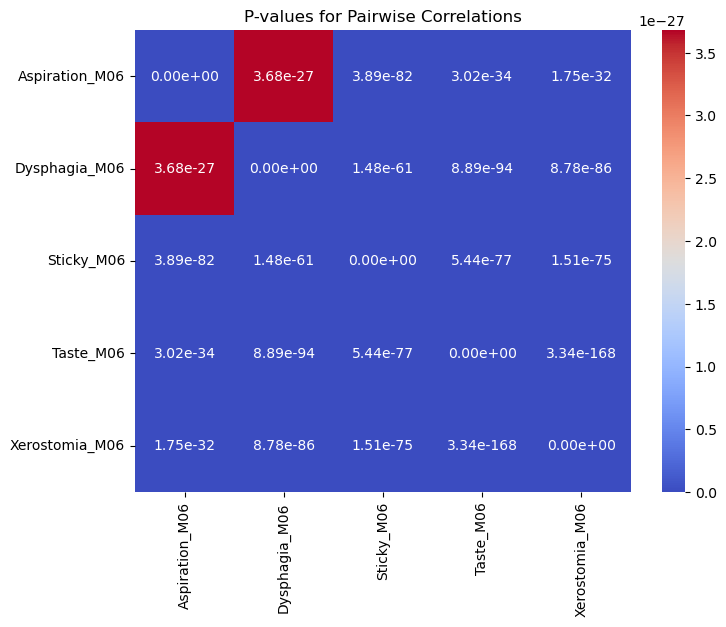

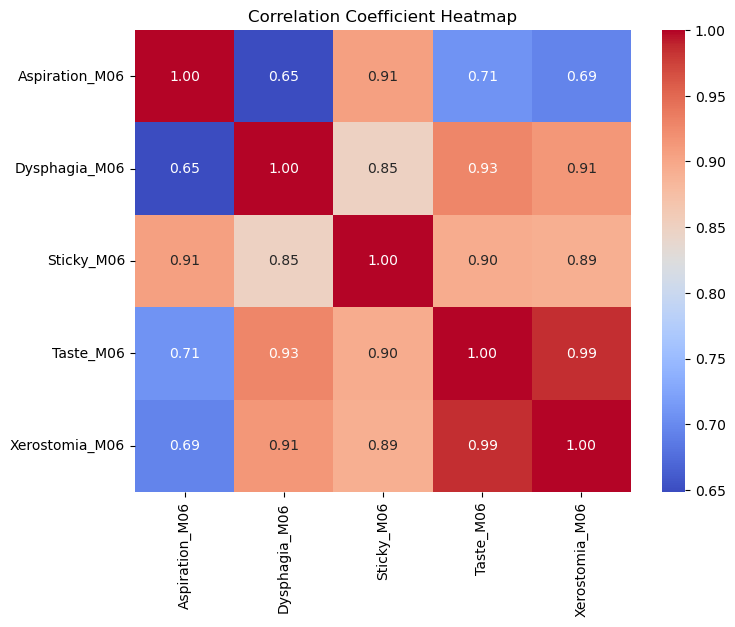

In [439]:
from scipy.stats import pearsonr, spearmanr

# Calculate p-values for pairwise correlations
p_values = pd.DataFrame(index=toxicity_columns, columns=toxicity_columns)

for col1 in toxicity_columns:
    for col2 in toxicity_columns:
        if col1 == col2:
            p_values.loc[col1, col2] = 0  # No p-value for self-correlation
        else:
            _, p_value = spearmanr(predictions[col1], predictions[col2])
            p_values.loc[col1, col2] = p_value

# Convert p-values to numeric for better readability
p_values = p_values.astype(float)

# Display the p-values
print("P-values for pairwise correlations:")
print(p_values)

# Plot the p-values heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(p_values, annot=True, cmap='coolwarm', fmt='.2e')
plt.title('P-values for Pairwise Correlations')
plt.show()

# Plot the correlation coefficient heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Coefficient Heatmap')
plt.show()


Conditional mean analysis for Aspiration_M06


C:\Users\macraedc\AppData\Local\Temp\ipykernel_13972\2758064395.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_probs = predictions.groupby('bin').mean()


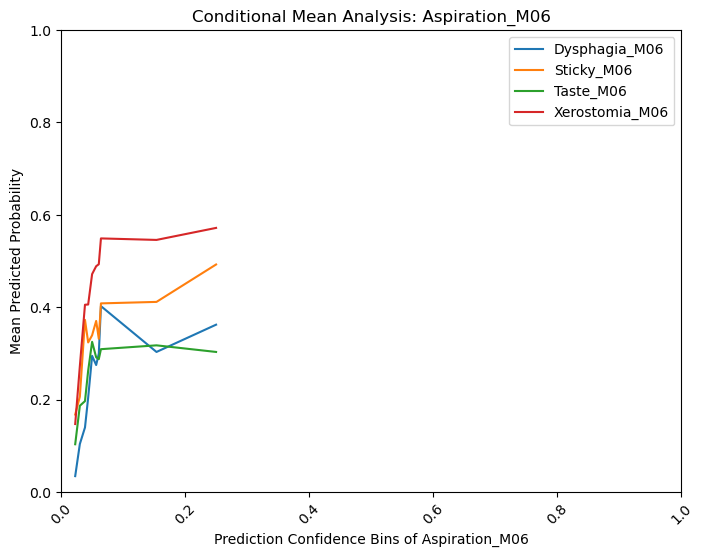

Conditional mean analysis for Dysphagia_M06


C:\Users\macraedc\AppData\Local\Temp\ipykernel_13972\2758064395.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_probs = predictions.groupby('bin').mean()


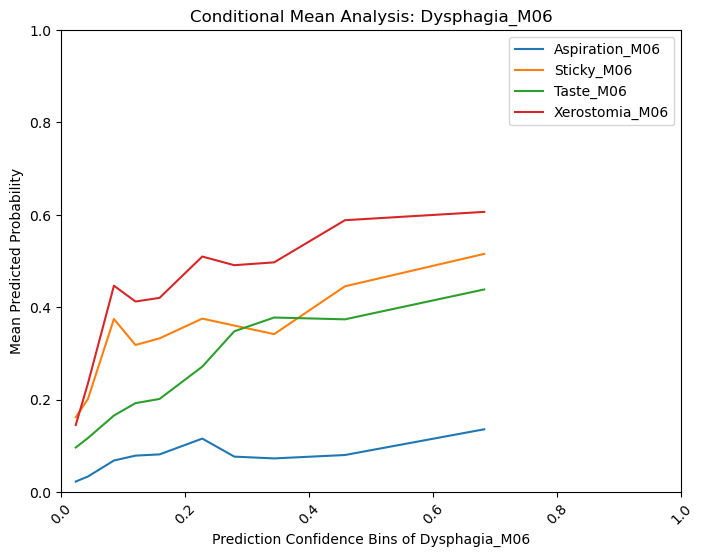

Conditional mean analysis for Sticky_M06


C:\Users\macraedc\AppData\Local\Temp\ipykernel_13972\2758064395.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_probs = predictions.groupby('bin').mean()


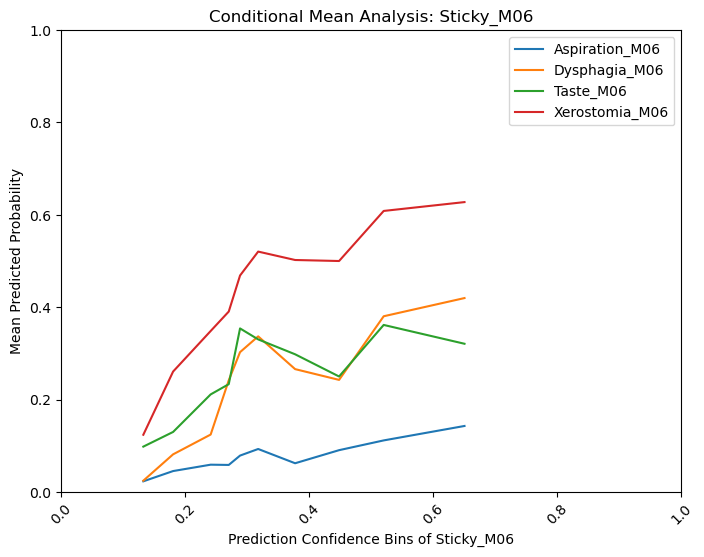

Conditional mean analysis for Taste_M06


C:\Users\macraedc\AppData\Local\Temp\ipykernel_13972\2758064395.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_probs = predictions.groupby('bin').mean()


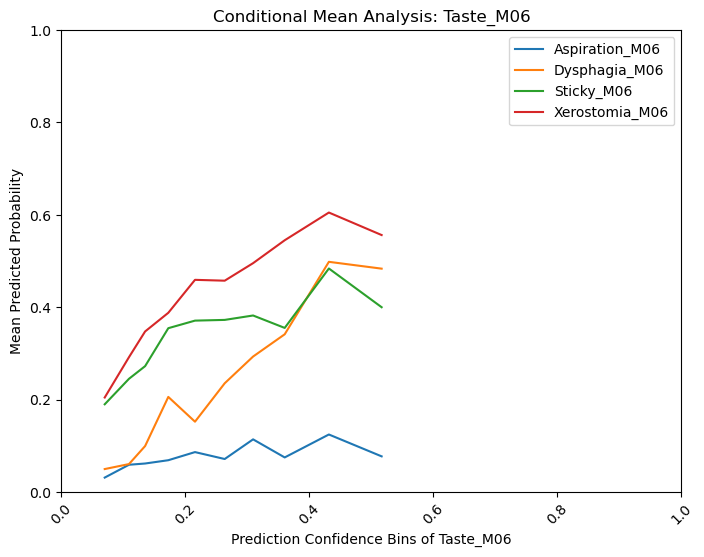

Conditional mean analysis for Xerostomia_M06


C:\Users\macraedc\AppData\Local\Temp\ipykernel_13972\2758064395.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_probs = predictions.groupby('bin').mean()


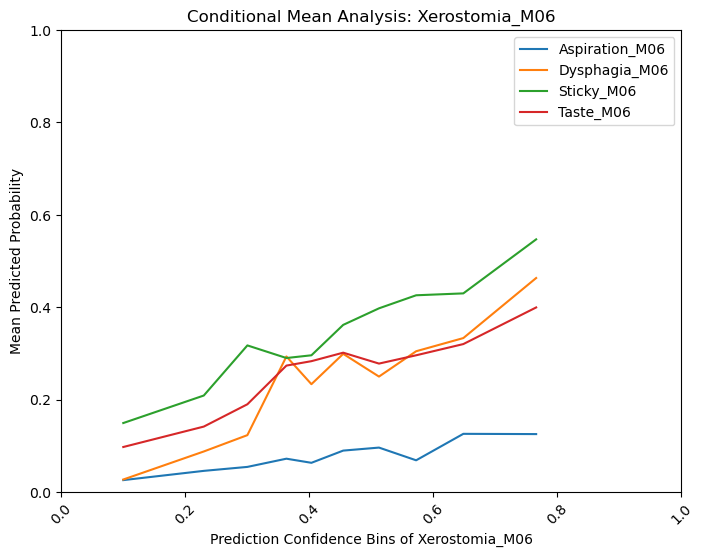

In [450]:
# Inter-Toxicity Correlation Analysis
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Load your predictions DataFrame (replace with actual file path or DataFrame)
predictions = df_predictions_only.copy()  # Replace with your DataFrame loading code


### 2. Conditional Prediction Analysis ###
def conditional_mean_analysis(predictions, primary_toxicity, bins=5):
    # Bin patients by prediction confidence for the primary toxicity
    predictions['bin'] = pd.qcut(predictions[primary_toxicity], q=bins, duplicates='drop')
    mean_probs = predictions.groupby('bin').mean()
    
    # Plot conditional means for each toxicity
    plt.figure(figsize=(8, 6))
    for toxicity in predictions.columns.drop(['bin', primary_toxicity]):
        plt.plot(mean_probs[primary_toxicity], mean_probs[toxicity], label=toxicity)
    plt.title(f'Conditional Mean Analysis: {primary_toxicity}')
    plt.xlabel(f'Prediction Confidence Bins of {primary_toxicity}')
    plt.ylabel('Mean Predicted Probability')
    plt.legend()
    plt.xticks(rotation=45)
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.show()

# def conditional_mean_analysis(predictions, primary_toxicity, bins=5):
#     # Bin patients by prediction confidence for the primary toxicity
#     predictions['bin'] = pd.qcut(predictions[primary_toxicity], q=bins, duplicates='drop')
#     mean_probs = predictions.groupby('bin').mean()
#     std_probs = predictions.groupby('bin').std()

#     # Plot conditional means for each toxicity with variance bars
#     plt.figure(figsize=(8, 6))
#     for toxicity in predictions.columns.drop(['bin', primary_toxicity]):
#         plt.errorbar(mean_probs[primary_toxicity], mean_probs[toxicity], yerr=std_probs[toxicity], label=toxicity, capsize=3)
#     plt.title(f'Conditional Mean Analysis: {primary_toxicity}')
#     plt.xlabel(f'Prediction Confidence Bins of {primary_toxicity}')
#     plt.ylabel('Mean Predicted Probability')
#     plt.legend()
#     plt.xticks(rotation=45)
#     plt.xlim(0, 1)
#     plt.show()





for endpoint in predictions.columns:
    if endpoint != 'bin':
        print(f"Conditional mean analysis for {endpoint}")
        conditional_mean_analysis(predictions, endpoint, bins=10)


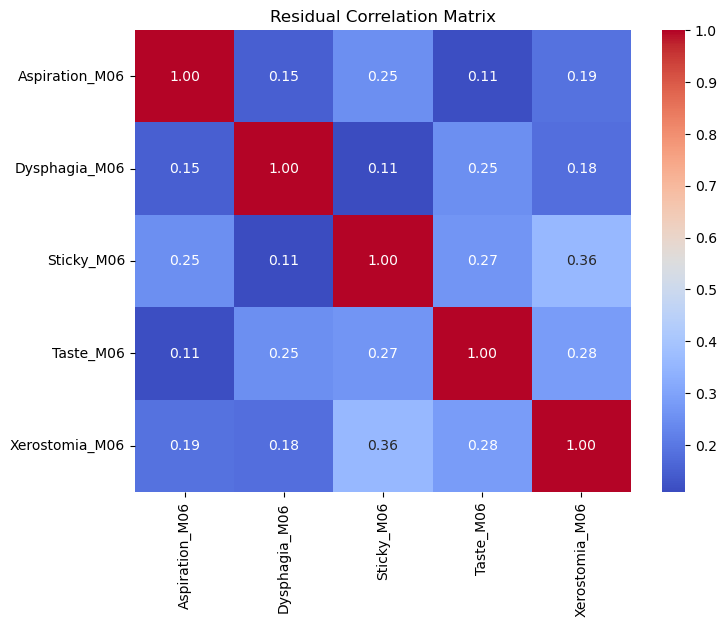

In [441]:

### 3. Residual Dependency Analysis ###
# Assuming you have the true labels in a separate DataFrame (true_labels)
predictions = df_predictions_only.copy()  # Replace with actual predictions loading code
true_labels = df_labels_only.copy() # pd.DataFrame()  # Replace with actual true labels loading code

# Calculate residuals for each toxicity
residuals = predictions - true_labels
residuals[true_labels == -1] = None

# Correlation matrix of residuals
residual_correlation = residuals.corr(method='pearson')

# Plot the residual correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(residual_correlation, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Residual Correlation Matrix')
plt.show()

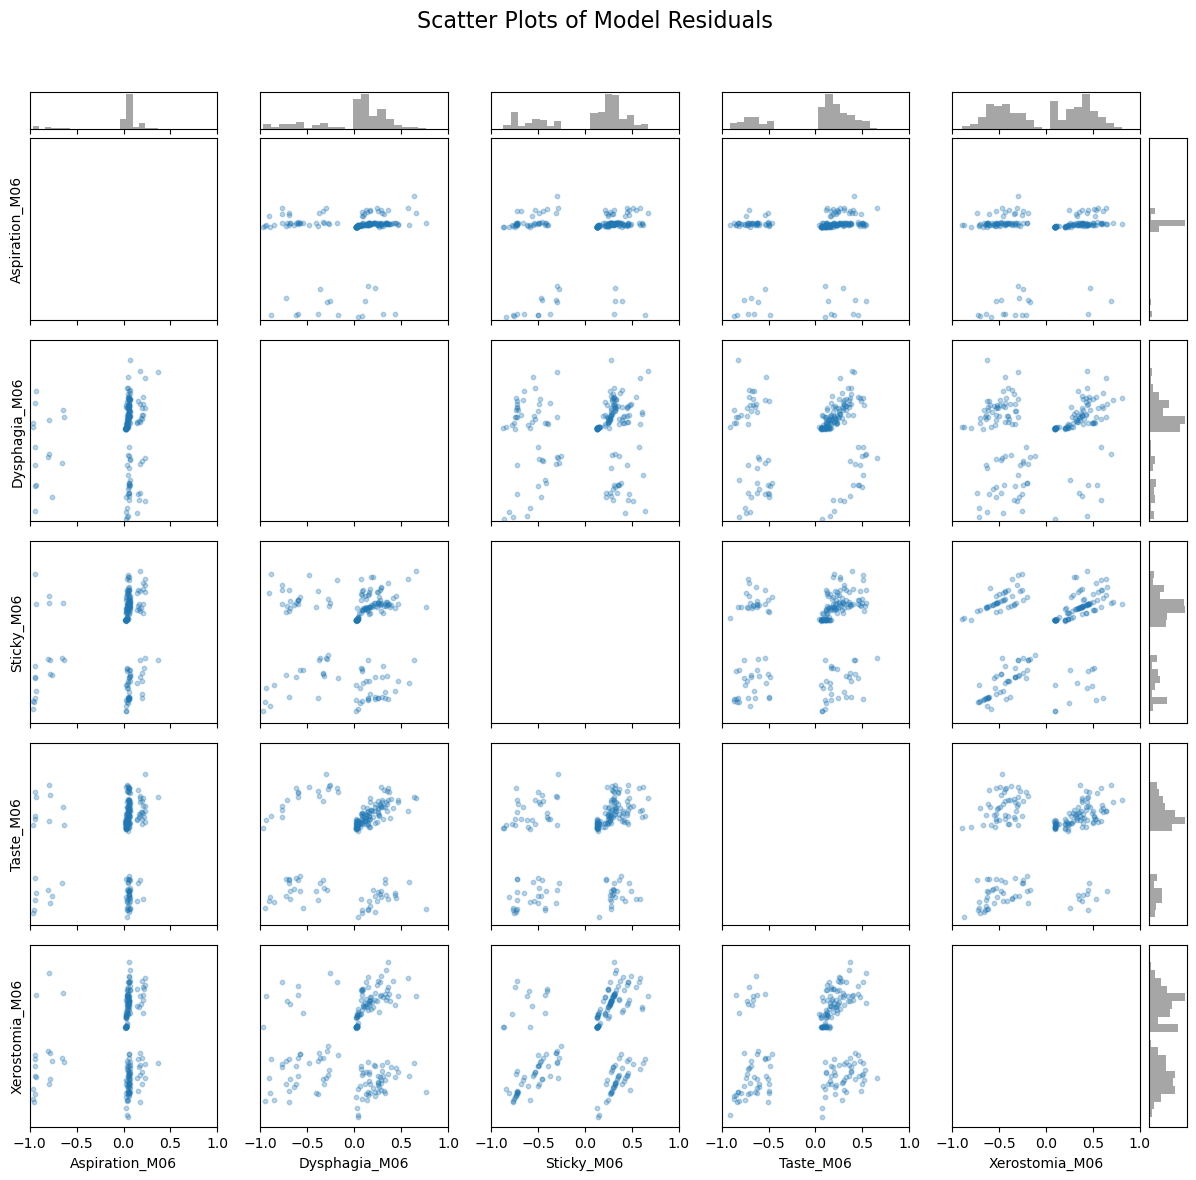

In [451]:
predictions = df_predictions_only.copy()  # Replace with actual predictions loading code
true_labels = df_labels_only.copy() # pd.DataFrame()  # Replace with actual true labels loading code

# Calculate residuals for each toxicity
residuals = predictions - true_labels 
residuals[true_labels == -1] = None

# residuals[residuals < 0] += 1


fig, axes = plt.subplots(num_toxicities, num_toxicities, figsize=(12, 12), sharex=True, sharey=True)
fig.suptitle('Scatter Plots of Model Residuals', fontsize=16)

catcol = 'Loctum3'
categories = df_preds[catcol].value_counts().index.tolist()
colors = np.linspace(0, 1, len(categories)) / 2
colordict = dict(zip(categories, colors)) 
df_preds["Color"] = df_preds[catcol].apply(lambda x: colordict[x])

for i, col1 in enumerate(toxicity_columns):
    for j, col2 in enumerate(toxicity_columns):
        ax = axes[i, j]
        ax.set_xlim(-1, 1)
        ax.set_ylim(-1, 1)
        if i == j:
            #ax.text(0, 0, col1, fontsize=10, ha='center', va='center')
            ax.set_xticks([])
            ax.set_yticks([])
        else:
            scatter = ax.scatter(residuals[col2], residuals[col1], s=10, alpha=0.3)#  , cmap='Dark2')
            # if i == 0 and j == 1:  # Add legend only once
            #     handles, labels = scatter.legend_elements(prop="colors", alpha=0.6)
            #     legend_labels = [f"{cat}" for cat in categories]
            #     ax.legend(handles, legend_labels, title=catcol)

        if j == 0:
            ax.set_ylabel(col1)
            ax.set_yticks([-1, -0.5, 0, 0.5, 1])
        if j == num_toxicities - 1:
            ax_histy = ax.inset_axes([1.05, 0, 0.2, 1], sharey=ax)
            ax_histy.hist(residuals[col1], bins=20, color='gray', alpha=0.7, orientation='horizontal')
            ax_histy.tick_params(axis='y', labelleft=False)
            ax_histy.set_xticks([])

        if i == 0:
            ax_histx = ax.inset_axes([0, 1.05, 1, 0.2], sharex=ax)
            ax_histx.hist(residuals[col2], bins=20, color='gray', alpha=0.7)
            ax_histx.tick_params(axis='x', labelbottom=False)
            ax_histx.set_yticks([])

        if i == num_toxicities - 1:
            ax.set_xlabel(col2)
            ax.set_xticks([-1, -0.5, 0, 0.5, 1])

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

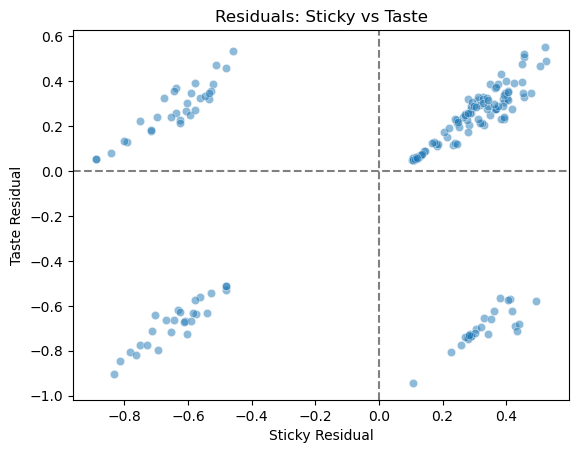

In [443]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(x=residuals['Sticky_M06'], y=residuals['Taste_M06'], alpha=0.5)
#sns.regplot(x=residuals['Sticky_M06'], y=residuals['Taste_M06'], scatter=False, color='red')
plt.axhline(0, linestyle='--', color='gray')
plt.axvline(0, linestyle='--', color='gray')
plt.title('Residuals: Sticky vs Taste')
plt.xlabel('Sticky Residual')
plt.ylabel('Taste Residual')
plt.show()

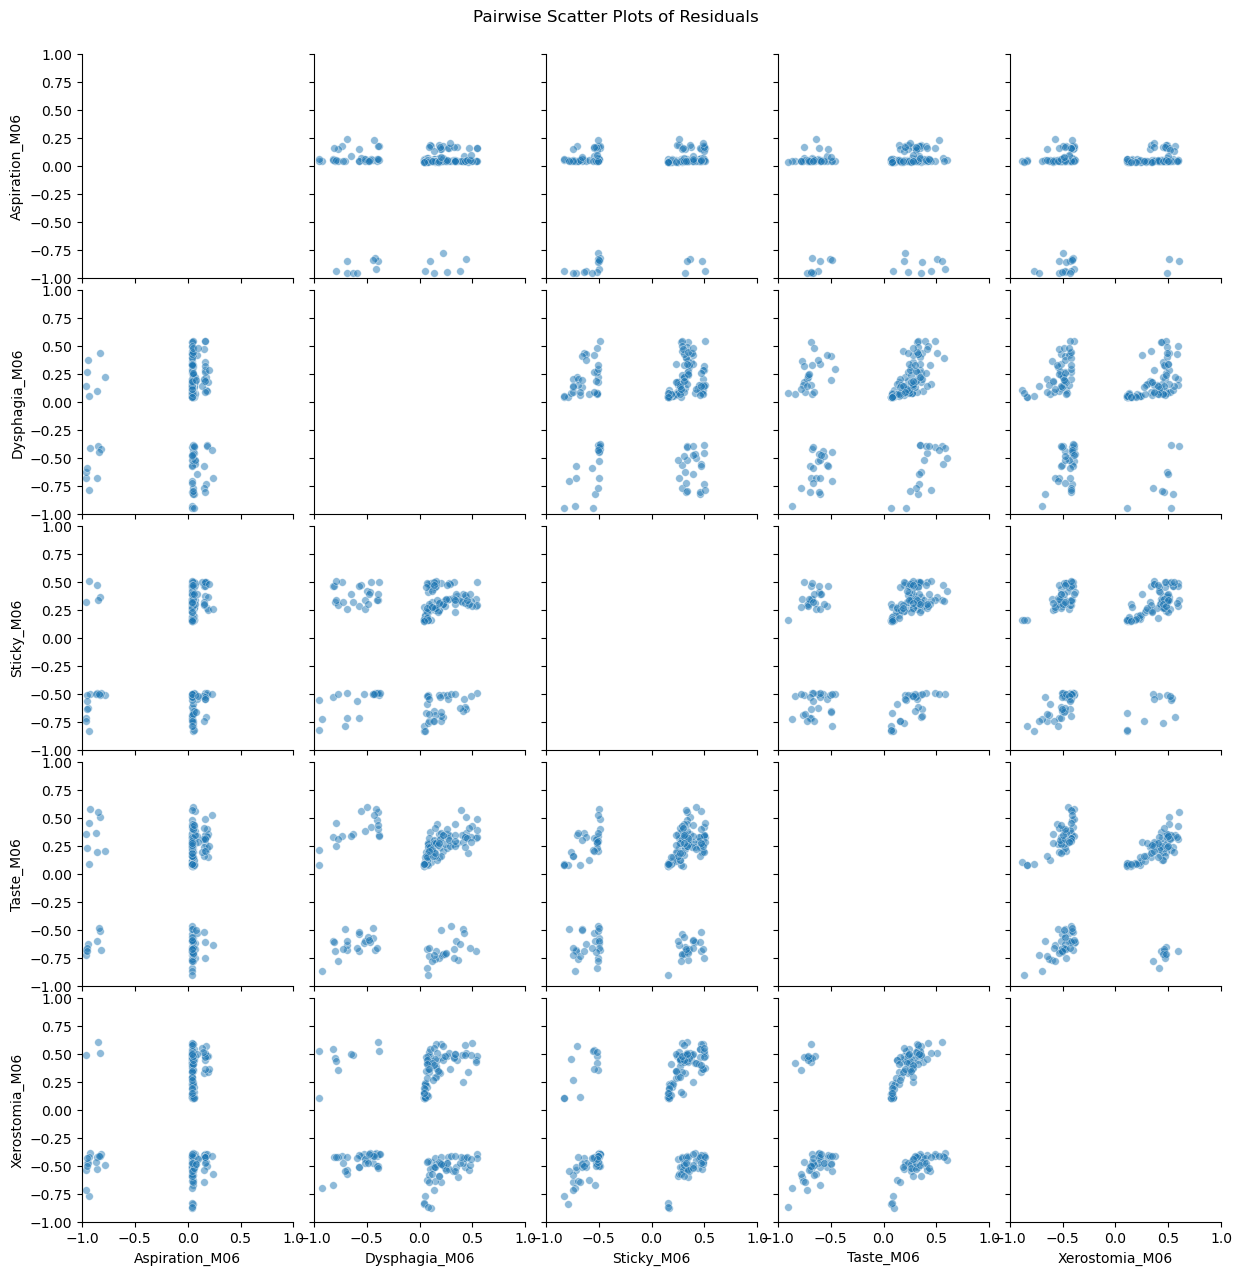

In [405]:
g = sns.pairplot(residuals, kind='scatter', plot_kws={'alpha': 0.5, 's': 30}, diag_kind=False, dropna=True)

# Set x and y limits for all subplots
for ax in g.axes.flatten():
    ax.set_xlim(-1, 1)
    ax.set_ylim(-1, 1)

plt.suptitle("Pairwise Scatter Plots of Residuals", y=1.02)
plt.show()


In [358]:
len(residuals)

216

c:\Users\macraedc\AppData\Local\miniconda3\envs\HNC_env\Lib\site-packages\sklearn\manifold\_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


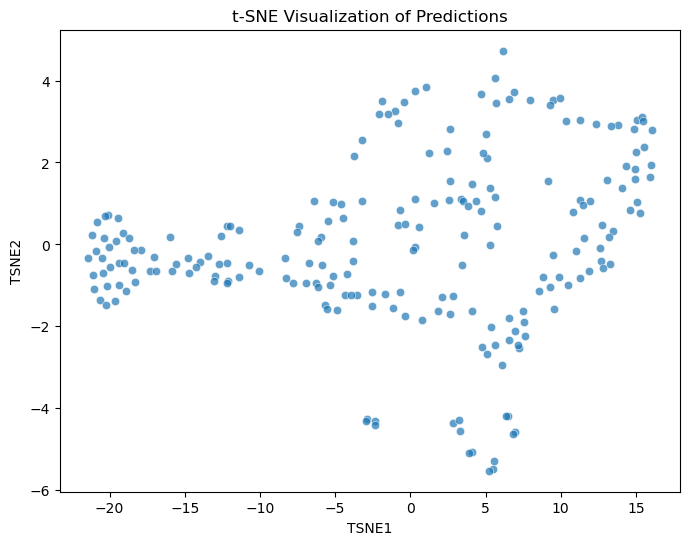

In [67]:
from sklearn.manifold import TSNE
import seaborn as sns

import matplotlib.pyplot as plt

# Perform t-SNE on the predictions
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
tsne_results = tsne.fit_transform(df_predictions_only)

# Create a DataFrame for the t-SNE results
tsne_df = pd.DataFrame(tsne_results, columns=['TSNE1', 'TSNE2'])

# Plot the t-SNE results
plt.figure(figsize=(8, 6))
sns.scatterplot(x='TSNE1', y='TSNE2', data=tsne_df, alpha=0.7)
plt.title('t-SNE Visualization of Predictions')
plt.xlabel('TSNE1')
plt.ylabel('TSNE2')
plt.show()